In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hamidgujjar/tomato-leaf-disease-detection-dataset/dataset_yolo/data.yaml
/kaggle/input/datasets/hamidgujjar/tomato-leaf-disease-detection-dataset/dataset_yolo/labels/val/collage_1286_jpg.rf.2895c35ae55b22d9281ec964cfc314c1.txt
/kaggle/input/datasets/hamidgujjar/tomato-leaf-disease-detection-dataset/dataset_yolo/labels/val/4682.txt
/kaggle/input/datasets/hamidgujjar/tomato-leaf-disease-detection-dataset/dataset_yolo/labels/val/11184.txt
/kaggle/input/datasets/hamidgujjar/tomato-leaf-disease-detection-dataset/dataset_yolo/labels/val/17383.txt
/kaggle/input/datasets/hamidgujjar/tomato-leaf-disease-detection-dataset/dataset_yolo/labels/val/collage_1422_jpg.rf.09bd5f20116f1548ff6c3cf9af5dacb6.txt
/kaggle/input/datasets/hamidgujjar/tomato-leaf-disease-detection-dataset/dataset_yolo/labels/val/15237.txt
/kaggle/input/datasets/hamidgujjar/tomato-leaf-disease-detection-dataset/dataset_yolo/labels/val/SM-2-_jpg.rf.d4e123c3e0ff8f3e1bedd96a2ec96a2a.txt
/kaggle/input/datasets

# Environment Setup & Data Loading

In [2]:
import os
import random
from pathlib import Path
import yaml
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Base paths
DATASET_DIR = Path("/kaggle/input/datasets/hamidgujjar/tomato-leaf-disease-detection-dataset/dataset_yolo")
YAML_PATH = DATASET_DIR / "data.yaml"
IMAGES_DIR = DATASET_DIR / "images"
LABELS_DIR = DATASET_DIR / "labels"

# Load YAML mapping
with open(YAML_PATH, "r") as f:
    yaml_config = yaml.safe_load(f)

# Extract class dictionary
raw_names = yaml_config.get("names", {})
if isinstance(raw_names, list):
    CLASS_MAP = {i: name for i, name in enumerate(raw_names)}
else:
    CLASS_MAP = {int(k): v for k, v in raw_names.items()}

print(f"Loaded YAML successfully.")
print(f"Total Classes Defined: {len(CLASS_MAP)}")
print("Class Mapping:")
for cid, cname in CLASS_MAP.items():
    print(f"  [{cid}] -> {cname}")

Loaded YAML successfully.
Total Classes Defined: 9
Class Mapping:
  [0] -> Early Blight
  [1] -> Healthy
  [2] -> Late Blight
  [3] -> Leaf Miner
  [4] -> Leaf Mold
  [5] -> Tomato Mosaic Virus
  [6] -> Septoria Leaf Spot
  [7] -> Red Spider Mite
  [8] -> TYLCV


# Preprocessing & Per-Split Annotation Stats

In [3]:
def inspect_split_annotations(splits=["train", "val", "test"]):
    split_summary = []
    class_stats = {split: {cid: 0 for cid in CLASS_MAP.keys()} for split in splits}

    for split in splits:
        img_folder = IMAGES_DIR / split
        lbl_folder = LABELS_DIR / split

        if not img_folder.exists():
            continue

        # Get valid images
        valid_extensions = ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG")
        images = []
        for ext in valid_extensions:
            images.extend(list(img_folder.glob(ext)))

        total_boxes = 0
        missing_labels = 0

        for img_path in images:
            lbl_path = lbl_folder / f"{img_path.stem}.txt"
            if not lbl_path.exists():
                missing_labels += 1
                continue

            with open(lbl_path, "r") as lf:
                lines = lf.readlines()
                total_boxes += len(lines)
                for line in lines:
                    parts = line.strip().split()
                    if parts:
                        cls_id = int(parts[0])
                        if cls_id in class_stats[split]:
                            class_stats[split][cls_id] += 1

        split_summary.append(
            {
                "Split": split,
                "Total Images": len(images),
                "Missing Label Files": missing_labels,
                "Total Bounding Boxes": total_boxes,
            }
        )

    # Convert to DataFrames
    df_splits = pd.DataFrame(split_summary)
    df_classes = pd.DataFrame(class_stats)
    df_classes["Class Name"] = df_classes.index.map(CLASS_MAP)
    df_classes = df_classes[["Class Name"] + [s for s in splits if s in df_classes.columns]]

    return df_splits, df_classes


df_splits, df_classes = inspect_split_annotations()

print("--- Train / Val / Test Summary ---")
print(df_splits.to_string(index=False))
print("\n--- Class Annotation Counts per Split ---")
print(df_classes.to_string(index=True))

--- Train / Val / Test Summary ---
Split  Total Images  Missing Label Files  Total Bounding Boxes
train         10583                    0                 44153
  val          2645                    0                 11084

--- Class Annotation Counts per Split ---
            Class Name  train   val  test
0         Early Blight   3533   908     0
1              Healthy   8825  2564     0
2          Late Blight   3382   658     0
3           Leaf Miner   4505  1028     0
4            Leaf Mold   4768  1321     0
5  Tomato Mosaic Virus   3623   722     0
6   Septoria Leaf Spot   4139  1039     0
7      Red Spider Mite   4462  1119     0
8                TYLCV   6916  1725     0


# Plot Class Distributions

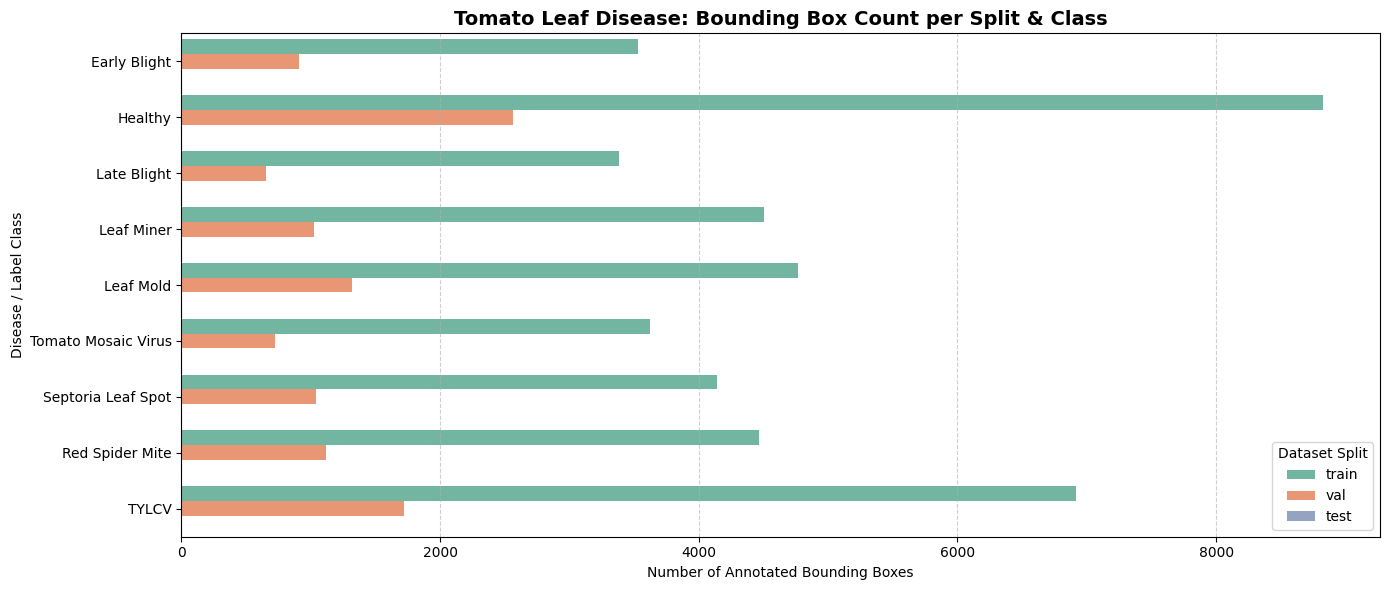

In [4]:
# Melt dataset for visualization
df_melted = df_classes.melt(
    id_vars=["Class Name"], var_name="Split", value_name="Bounding Boxes"
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=df_melted,
    x="Bounding Boxes",
    y="Class Name",
    hue="Split",
    palette="Set2",
)
plt.title("Tomato Leaf Disease: Bounding Box Count per Split & Class", fontsize=14, fontweight="bold")
plt.xlabel("Number of Annotated Bounding Boxes")
plt.ylabel("Disease / Label Class")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.legend(title="Dataset Split")
plt.tight_layout()
plt.show()

# Image Bounding Box Visualization

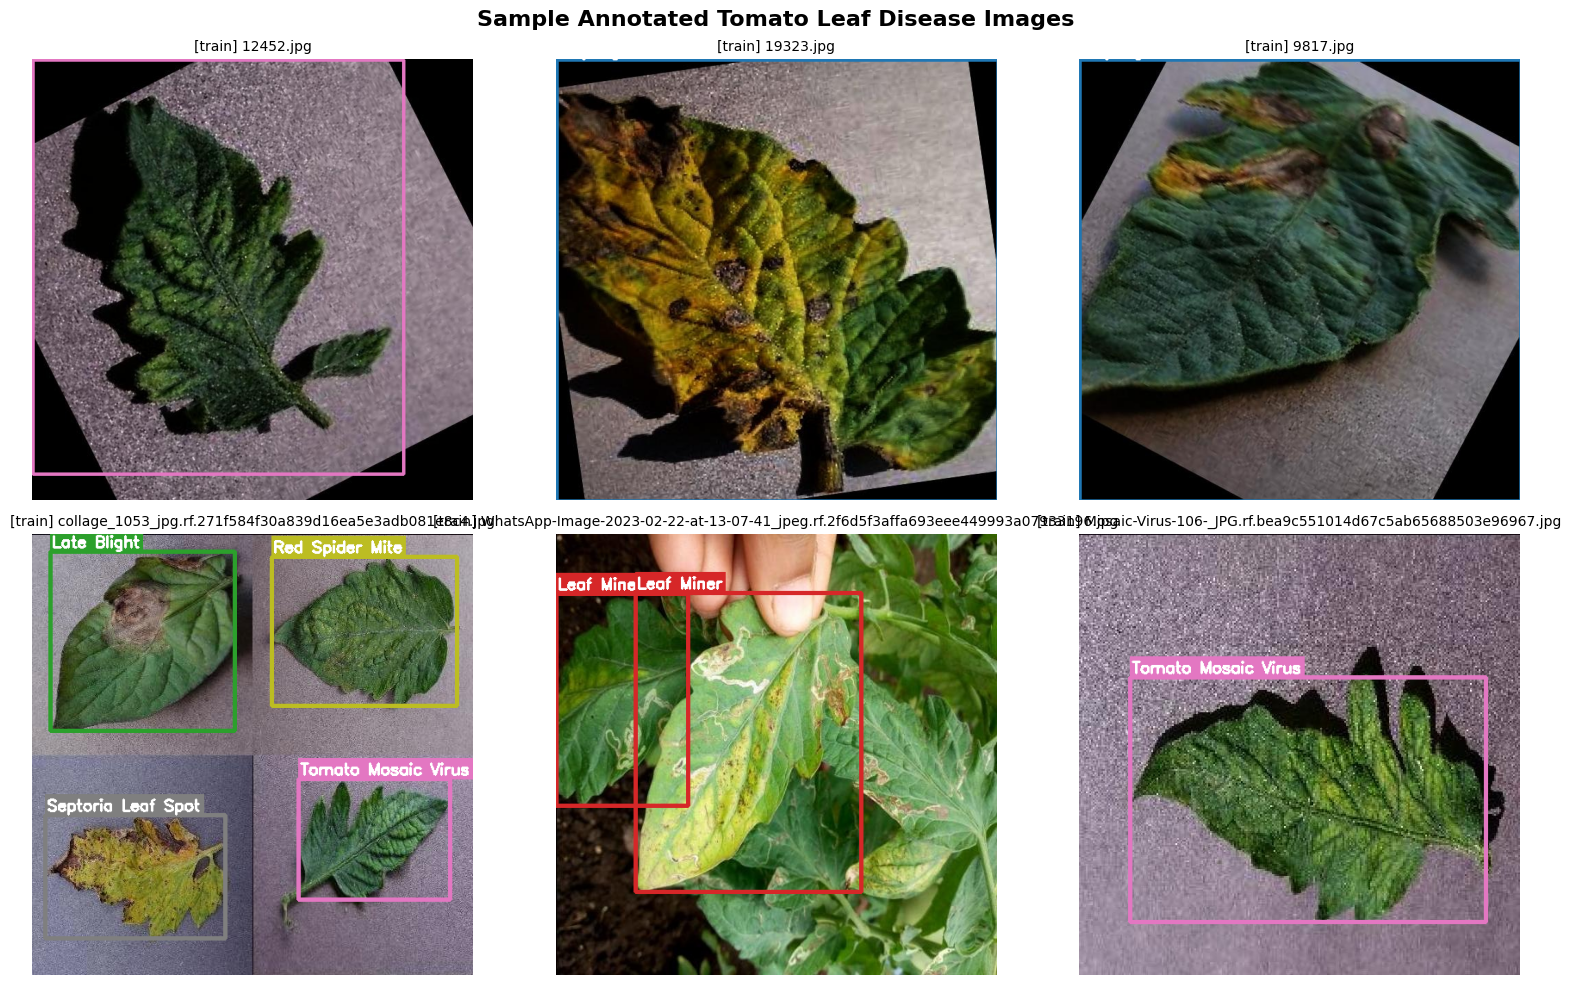

In [5]:
def draw_yolo_boxes(image_path, label_path, class_map):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    if not label_path.exists():
        return image

    # Distinct colors for drawing
    colors = plt.cm.tab10(np.linspace(0, 1, len(class_map)))

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            cls_id = int(parts[0])
            x_center, y_center, bw, bh = map(float, parts[1:5])

            # Denormalize coordinates
            xmin = int((x_center - bw / 2) * w)
            ymin = int((y_center - bh / 2) * h)
            xmax = int((x_center + bw / 2) * w)
            ymax = int((y_center + bh / 2) * h)

            # Class metadata
            class_name = class_map.get(cls_id, f"Class {cls_id}")
            color = [int(c * 255) for c in colors[cls_id % len(colors)][:3]]

            # Bounding box & text background
            cv2.rectangle(image, (xmin, ymin), (xmax, ymax), color, 3)
            label_text = f"{class_name}"
            (text_w, text_h), baseline = cv2.getTextSize(
                label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2
            )
            cv2.rectangle(
                image,
                (xmin, ymin - text_h - 10),
                (xmin + text_w + 4, ymin),
                color,
                -1,
            )
            cv2.putText(
                image,
                label_text,
                (xmin + 2, ymin - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 255, 255),
                2,
            )

    return image


def show_random_samples(split="train", num_samples=6):
    img_folder = IMAGES_DIR / split
    lbl_folder = LABELS_DIR / split

    all_images = list(img_folder.glob("*.jpg")) + list(img_folder.glob("*.png"))
    if not all_images:
        print(f"No images found in {img_folder}")
        return

    sample_paths = random.sample(all_images, min(num_samples, len(all_images)))

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for idx, img_path in enumerate(sample_paths):
        lbl_path = lbl_folder / f"{img_path.stem}.txt"
        annotated_img = draw_yolo_boxes(img_path, lbl_path, CLASS_MAP)

        axes[idx].imshow(annotated_img)
        axes[idx].set_title(f"[{split}] {img_path.name}", fontsize=10)
        axes[idx].axis("off")

    plt.suptitle("Sample Annotated Tomato Leaf Disease Images", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Display samples from training set
show_random_samples(split="train", num_samples=6)